# LPPLS Bubble Detection — Data Preparation

Generates LPPLS-based bubble dummy columns (`_BD`) for all four metals and saves the result
as `R/df_master_lppls.csv` in the **same format** as `R/df_master.csv` (semicolon-separated, comma decimal).

**This mirrors the role of `R/metals30_data_prep.R`** but replaces GSADF with the
Log-Periodic Power Law Singularity (LPPLS) confidence indicator.

| Step | Description |
|------|-------------|
| 1 | Load base dataset (`df_master.csv`) — prices + macro/market already assembled by R |
| 2 | Apply LPPLS nested rolling-window fit to each metal's log-price series |
| 3 | Apply trend filter (bubble only if price is rising vs 5 days ago) — matches R pipeline |
| 4 | Compare bubble prevalence with original GSADF labels |
| 5 | Save `df_master_lppls.csv` with replaced `_BD` columns |

**⚠ Runtime:** The nested fits with `outer_increment=1` take ~10–25 min per metal on 4 workers.
Intermediate results are printed to track progress. A cached confidence CSV is also saved so
you can reload without rerunning.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, warnings
warnings.filterwarnings('ignore')

from lppls import lppls as lppls_mod

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'
os.makedirs('../../outputs', exist_ok=True)

print('Packages loaded.')


Packages loaded.


## 1. Load Base Dataset

`df_master.csv` already contains the DALY price series and all macro/market variables
assembled by `R/metals30_data_prep.R`. We only need to replace the `_BD` columns.


In [2]:
df = pd.read_csv('../../R/df_master.csv', sep=';', decimal=',', index_col=0)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

metals = {'Cobalt': 'CODALY', 'Copper': 'CUDALY', 'Lithium': 'LIDALY', 'Nickel': 'NIDALY'}
bubble_cols = [c for c in df.columns if c.endswith('_BD')]

print(f'Dataset: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Period:  {df["Date"].min().date()} to {df["Date"].max().date()}')
print()
print('GSADF bubble prevalence (reference):')
for name, col in metals.items():
    bd = df[col + '_BD']
    print(f'  {name:10s}: {int(bd.sum()):4d} days  ({100*bd.mean():.1f}%)')


Dataset: 2152 rows × 21 columns
Period:  2017-05-10 to 2025-10-31

GSADF bubble prevalence (reference):
  Cobalt    :  230 days  (10.7%)
  Copper    :   39 days  (1.8%)
  Lithium   : 1089 days  (50.6%)
  Nickel    :   26 days  (1.2%)


## 2. LPPLS Confidence Computation

The LPPLS model fits:

$$E[\ln p(t)] = A + B(t_c - t)^m + C(t_c - t)^m \cos\big(\omega \ln(t_c - t) - \phi\big)$$

A **nested rolling-window** approach: for each day $t$, many windows of varying lengths
ending at $t$ are fitted. The **positive confidence** (`pos_conf`) is the fraction of
windows whose fit parameters satisfy the LPPLS filter conditions
(valid $m$, $\omega$, damping ratio, oscillation count). High confidence → explosive upward phase.

**Parameters:**
- `window_size=120` — outer window (days)
- `smallest_window_size=30` — inner window minimum
- `outer_increment=1` — compute every single day (most precise, but slow)
- `threshold=0.3` — fraction of valid fits to flag as bubble (conservative; LPPLS naturally sparse)

Confidence is forward-filled over gaps ≤5 days to bridge minor fitting gaps.


In [3]:
CONF_THRESHOLD = 0.3   # fraction of valid fits to declare a bubble
FFILL_LIMIT    = 5     # forward-fill confidence over gaps of up to 5 days
CACHE_PATH     = '../../R/lppls_confidence.csv'

# Try to load cached results so re-running the notebook is fast
if os.path.exists(CACHE_PATH):
    conf_cache = pd.read_csv(CACHE_PATH, index_col=0)
    conf_cache['Date'] = pd.to_datetime(conf_cache['Date'])
    print(f'Loaded cached confidence from {CACHE_PATH}')
    cached = True
else:
    conf_cache = None
    cached = False

lppls_confidence = {}   # {metal: np.ndarray of pos_conf per row}
lppls_raw_flags  = {}   # before trend filter

dates_ord = np.array([pd.Timestamp(d).toordinal() for d in df['Date']])

for metal, col in metals.items():
    print(f'\n--- {metal} ({col}) ---')

    # --- Use cached confidence if available ---
    if cached and col + '_conf' in conf_cache.columns:
        conf_filled = conf_cache[col + '_conf'].values
        print(f'  Using cached confidence  (max={conf_filled.max():.3f})')
    else:
        prices     = df[col].values
        log_prices = np.log(np.maximum(prices, 0.001))
        observations = np.array([dates_ord, log_prices])

        model = lppls_mod.LPPLS(observations=observations)

        try:
            res = model.mp_compute_nested_fits(
                workers=4,
                window_size=120,
                smallest_window_size=30,
                outer_increment=1,   # every trading day — most precise
                inner_increment=5,
                max_searches=25
            )
            indicators = model.compute_indicators(res)
        except Exception as e:
            print(f'  LPPLS fitting failed: {e}')
            conf_filled = np.zeros(len(df))
            lppls_confidence[metal] = conf_filled
            lppls_raw_flags[metal]  = np.zeros(len(df), dtype=int)
            continue

        # Map pos_conf back to full date index
        pos_conf = np.zeros(len(df))
        if indicators is not None and len(indicators) > 0:
            for _, row in indicators.iterrows():
                t_ord   = int(row['time'])
                matches = np.where(dates_ord == t_ord)[0]
                if len(matches) > 0:
                    pos_conf[matches[0]] = row['pos_conf']

        # Forward-fill over small gaps
        conf_filled = (pd.Series(pos_conf)
                       .replace(0, np.nan)
                       .ffill(limit=FFILL_LIMIT)
                       .fillna(0)
                       .values)

        print(f'  Computed.  max_conf={conf_filled.max():.3f}')

    lppls_confidence[metal] = conf_filled

    # Binary flag (before trend filter)
    bubble_flag = (conf_filled >= CONF_THRESHOLD).astype(int)
    lppls_raw_flags[metal] = bubble_flag

    n_raw = int(bubble_flag.sum())
    print(f'  Raw flags (conf≥{CONF_THRESHOLD}): {n_raw} days  ({100*n_raw/len(df):.1f}%)')

print('\nDone.')



--- Cobalt (CODALY) ---


100%|██████████| 2033/2033 [15:04<00:00,  2.25it/s]


  Computed.  max_conf=0.667
  Raw flags (conf≥0.3): 15 days  (0.7%)

--- Copper (CUDALY) ---


100%|██████████| 2033/2033 [12:53<00:00,  2.63it/s]


  Computed.  max_conf=0.500
  Raw flags (conf≥0.3): 31 days  (1.4%)

--- Lithium (LIDALY) ---


100%|██████████| 2033/2033 [13:11<00:00,  2.57it/s]


  Computed.  max_conf=0.500
  Raw flags (conf≥0.3): 16 days  (0.7%)

--- Nickel (NIDALY) ---


100%|██████████| 2033/2033 [12:11<00:00,  2.78it/s]


  Computed.  max_conf=0.833
  Raw flags (conf≥0.3): 26 days  (1.2%)

Done.


In [4]:
# Cache confidence values to CSV so rerunning is instant
if not cached:
    conf_df = pd.DataFrame({'Date': df['Date']})
    for metal, col in metals.items():
        if metal in lppls_confidence:
            conf_df[col + '_conf'] = lppls_confidence[metal]
    conf_df.to_csv(CACHE_PATH, index=True)
    print(f'Confidence saved → {CACHE_PATH}')
else:
    # Still populate lppls_confidence from cache for downstream cells
    for metal, col in metals.items():
        if col + '_conf' in conf_cache.columns and metal not in lppls_confidence:
            conf_filled = conf_cache[col + '_conf'].values
            lppls_confidence[metal] = conf_filled
            lppls_raw_flags[metal] = (conf_filled >= CONF_THRESHOLD).astype(int)
    print('Confidence dict populated from cache.')


Confidence saved → ../../R/lppls_confidence.csv


## 3. Trend Filter

Mirrors the R pipeline: within any flagged period, a day is only kept as a bubble
if the price is **strictly higher than 5 trading days ago**. This removes episodes where
LPPLS fires during a price plateau or decline (which the model can occasionally misidentify
as a slow-speed super-exponential phase).


In [5]:
TREND_LAG = 5   # same as R pipeline

lppls_bubbles = {}  # final filtered bubble flags

print('Trend filter (price[t] > price[t-5]):')
print(f'{"Metal":10s}  {"Raw":>6s}  {"Filtered":>8s}  {"Removed":>7s}')
print('-' * 40)

for metal, col in metals.items():
    if metal not in lppls_raw_flags:
        continue

    prices  = df[col].values
    raw     = lppls_raw_flags[metal].copy()
    filtered = raw.copy()

    for i in range(len(filtered)):
        if filtered[i] == 1 and i >= TREND_LAG:
            if prices[i] <= prices[i - TREND_LAG]:
                filtered[i] = 0

    lppls_bubbles[metal] = filtered

    n_raw  = int(raw.sum())
    n_filt = int(filtered.sum())
    print(f'{metal:10s}  {n_raw:6d}  {n_filt:8d}  {n_raw - n_filt:7d}')


Trend filter (price[t] > price[t-5]):
Metal          Raw  Filtered  Removed
----------------------------------------
Cobalt          15        14        1
Copper          31        24        7
Lithium         16        12        4
Nickel          26        19        7


## 4. Diagnostics — Bubble Period Plots & Prevalence Comparison

Visualize the LPPLS confidence indicator alongside the binary bubble flag, and compare
final prevalence with the original GSADF labels.


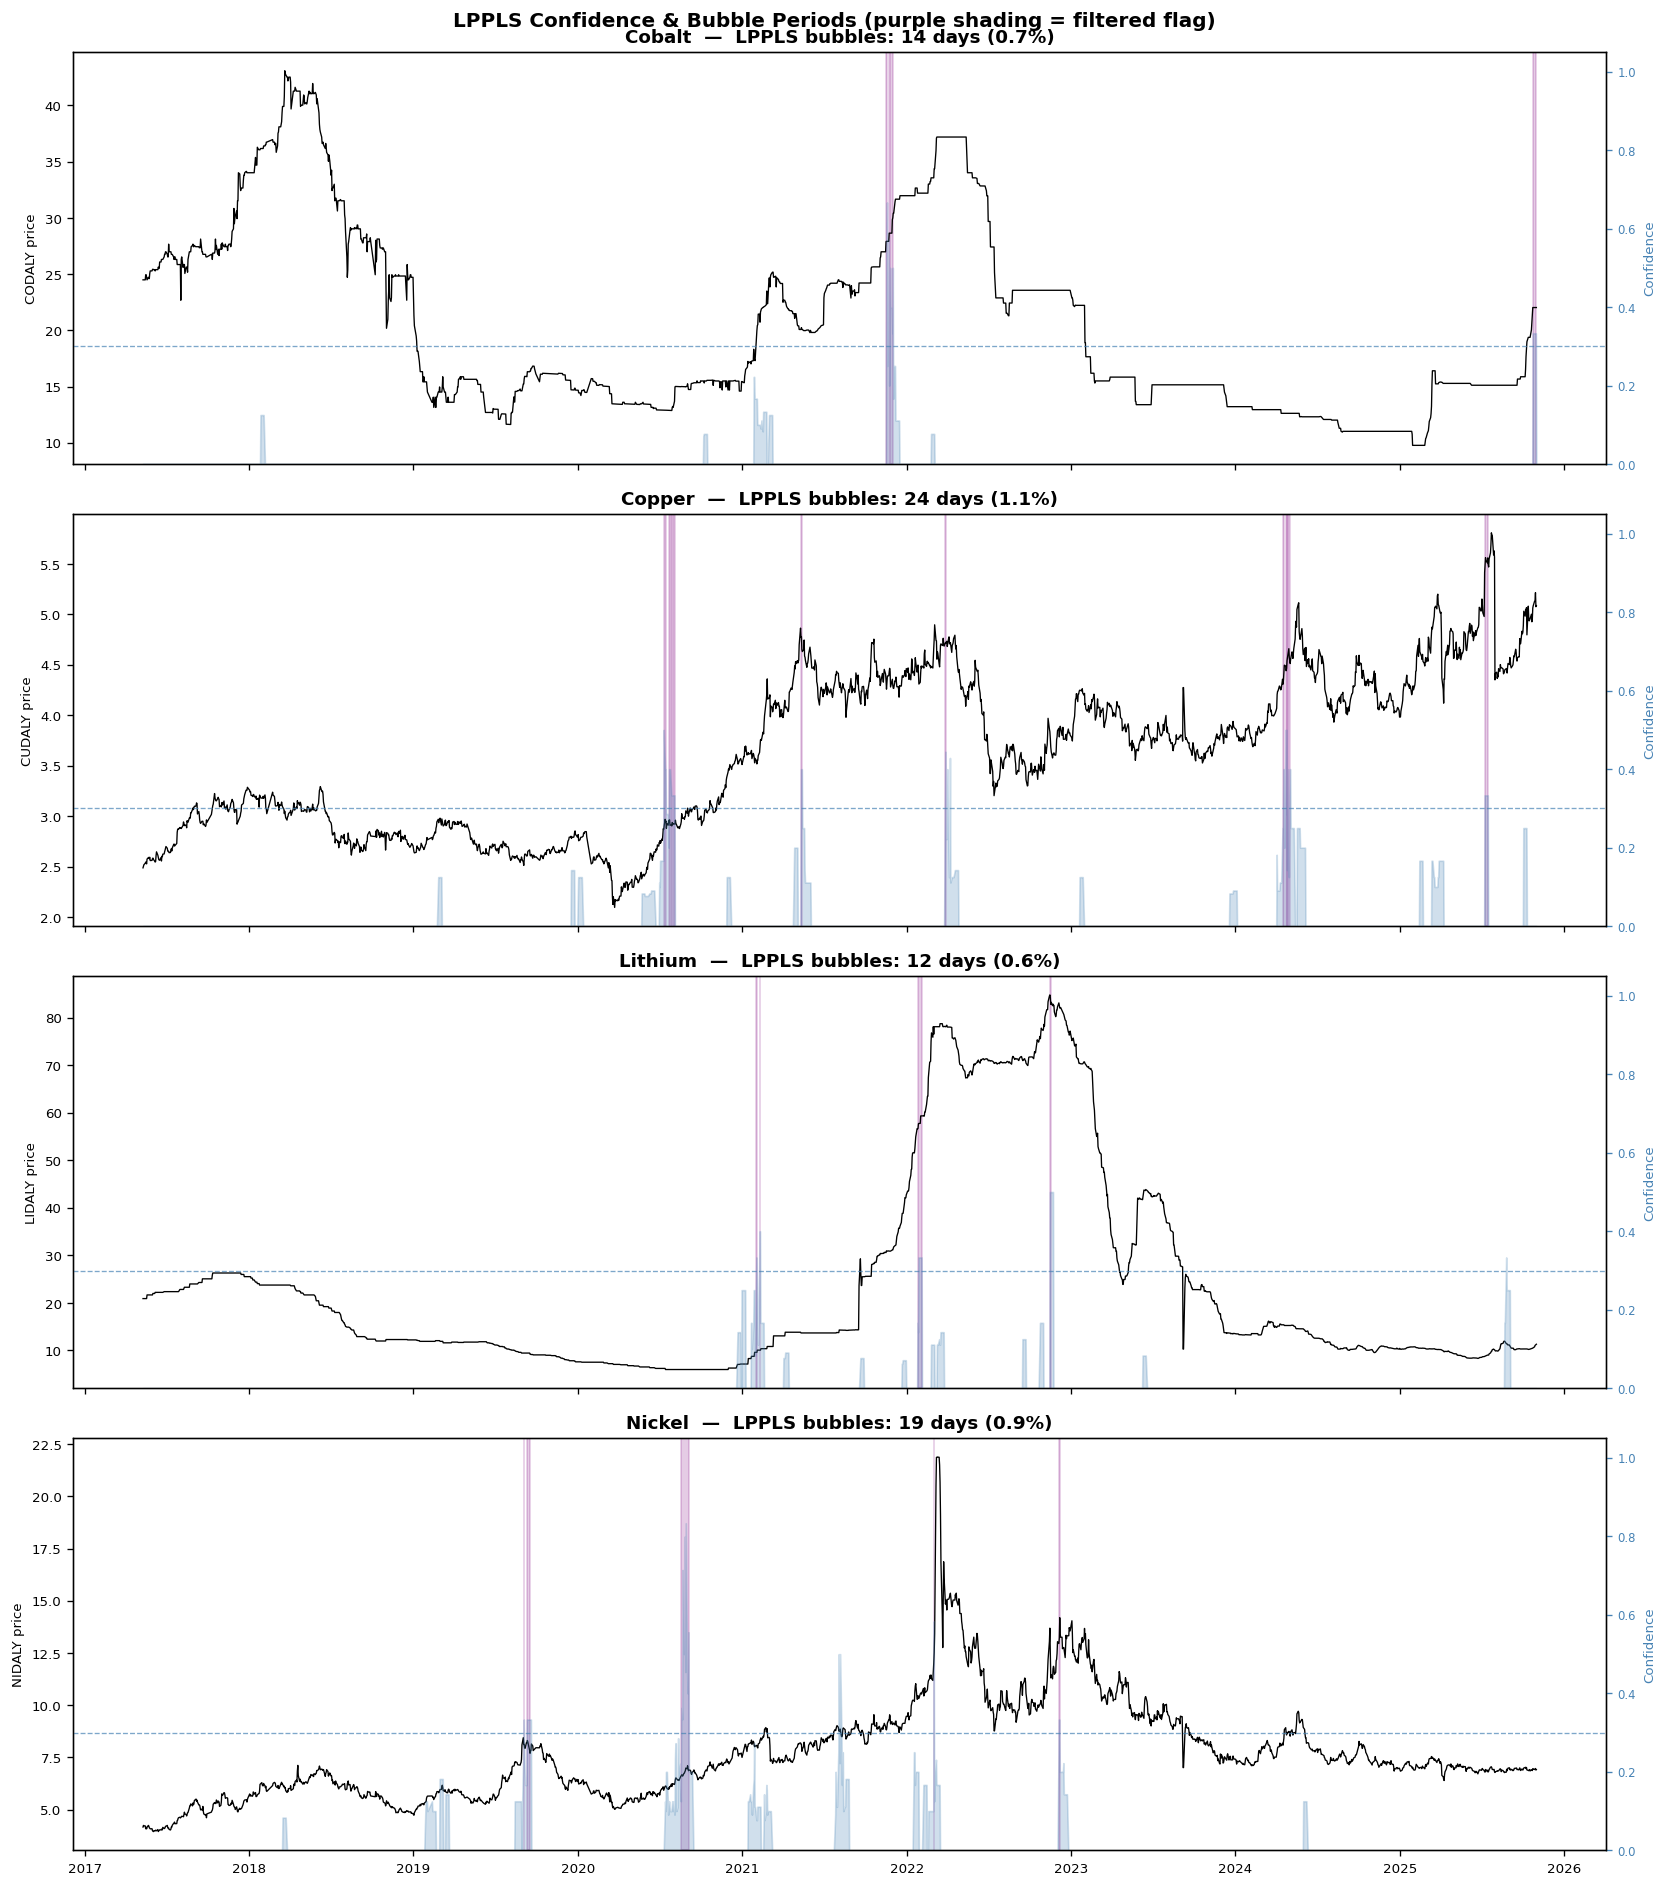

In [6]:
# Price + confidence + bubble shading per metal
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

for idx, (metal, col) in enumerate(metals.items()):
    ax  = axes[idx]
    ax2 = ax.twinx()

    # Price (primary axis)
    ax.plot(df['Date'], df[col], color='black', lw=0.8, label='Price')
    ax.set_ylabel(f'{col} price', fontsize=8)
    ax.tick_params(labelsize=8)

    # LPPLS confidence (secondary axis)
    if metal in lppls_confidence:
        conf = lppls_confidence[metal]
        ax2.fill_between(df['Date'], conf, alpha=0.25, color='steelblue', label='LPPLS conf')
        ax2.axhline(CONF_THRESHOLD, color='steelblue', lw=0.8, ls='--', alpha=0.7)
        ax2.set_ylim(0, 1.05)
        ax2.set_ylabel('Confidence', fontsize=8, color='steelblue')
        ax2.tick_params(labelsize=7, colors='steelblue')

    # Shade final bubble periods (after trend filter)
    if metal in lppls_bubbles:
        bub = lppls_bubbles[metal]
        in_b = False
        for i in range(len(bub)):
            if bub[i] == 1 and not in_b:
                s = df['Date'].iloc[i]; in_b = True
            elif (bub[i] == 0 or i == len(bub) - 1) and in_b:
                ax.axvspan(s, df['Date'].iloc[i], color='purple', alpha=0.2)
                in_b = False
        n_b = int(bub.sum())
        ax.set_title(f'{metal}  —  LPPLS bubbles: {n_b} days ({100*n_b/len(df):.1f}%)',
                     fontsize=11, fontweight='bold')

plt.suptitle('LPPLS Confidence & Bubble Periods (purple shading = filtered flag)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../../outputs/lppls_bubble_timelines.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()


In [7]:
# Prevalence comparison table
print(f'{"Metal":10s} | {"GSADF days":>10s} | {"GSADF %":>8s} | {"LPPLS days":>10s} | {"LPPLS %":>8s}')
print('-' * 60)
for metal, col in metals.items():
    gsadf_n   = int(df[col + '_BD'].sum())
    gsadf_pct = 100 * gsadf_n / len(df)
    lppls_n   = int(lppls_bubbles.get(metal, np.zeros(len(df))).sum())
    lppls_pct = 100 * lppls_n / len(df)
    print(f'{metal:10s} | {gsadf_n:10d} | {gsadf_pct:7.1f}% | {lppls_n:10d} | {lppls_pct:7.1f}%')


Metal      | GSADF days |  GSADF % | LPPLS days |  LPPLS %
------------------------------------------------------------
Cobalt     |        230 |    10.7% |         14 |     0.7%
Copper     |         39 |     1.8% |         24 |     1.1%
Lithium    |       1089 |    50.6% |         12 |     0.6%
Nickel     |         26 |     1.2% |         19 |     0.9%


## 5. Assemble & Save

Replace the `_BD` columns in `df_master` with the LPPLS-filtered flags and save as
`R/df_master_lppls.csv` using `sep=';', decimal=','` — identical format to `df_master.csv`.

Also saves the raw confidence values to `R/lppls_confidence.csv` for threshold sensitivity analysis.


In [8]:
df_out = df.copy()

# Replace _BD columns with LPPLS flags
for metal, col in metals.items():
    bd_col = col + '_BD'
    if metal in lppls_bubbles:
        df_out[bd_col] = lppls_bubbles[metal].astype(int)
    else:
        # Metal failed — set to zero and warn
        df_out[bd_col] = 0
        print(f'WARNING: {metal} LPPLS failed — {bd_col} set to 0.')

# Sanity checks
assert list(df_out.columns) == list(df.columns), 'Column mismatch!'
assert len(df_out) == len(df), 'Row count changed!'
print(f'Output shape: {df_out.shape}')
print(f'Columns:      {list(df_out.columns)}')
print()

# Save — same format as R write.csv2
out_path = '../../R/df_master_lppls.csv'
df_out.to_csv(out_path, sep=';', decimal=',')

size_kb = os.path.getsize(out_path) / 1024
print(f'Saved → {out_path}  ({size_kb:.1f} KB)')
print()

# Final prevalence check on saved file
check = pd.read_csv(out_path, sep=';', decimal=',', index_col=0)
print('Verification (re-read):')
for metal, col in metals.items():
    n = int(check[col + '_BD'].sum())
    print(f'  {metal:10s}: {n} days  ({100*n/len(check):.1f}%)')


Output shape: (2152, 21)
Columns:      ['Date', 'CODALY', 'CUDALY', 'LIDALY', 'NIDALY', 'OIL_WTI', 'GAS_HHUB', 'USD_INDEX', 'VIX', 'YIELD_10Y', 'GOLD_FUT', 'MSCI_ETF', 'MSCI_EM', 'SP500', 'QCLN', 'C_CHR', 'C_US', 'CODALY_BD', 'CUDALY_BD', 'LIDALY_BD', 'NIDALY_BD']

Saved → ../../R/df_master_lppls.csv  (412.2 KB)

Verification (re-read):
  Cobalt    : 14 days  (0.7%)
  Copper    : 24 days  (1.1%)
  Lithium   : 12 days  (0.6%)
  Nickel    : 19 days  (0.9%)
